In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)


DATA LOADING AND COLLECTING DATA THROUGH API

In [3]:
df = pd.read_csv("cumulative.csv")

In [4]:
df.shape

(9564, 50)

In [5]:
df.describe()

,rowid,kepid,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
count,9564.000000,9.564000e+03,8054.000000,9564.000000,9564.000000,9564.000000,9564.000000,9564.000000,9110.000000,9110.000000,...,9081.000000,9201.000000,9096.000000,9096.000000,9201.000000,9096.000000,9096.000000,9564.000000,9564.000000,9563.000000
mean,4782.500000,7.690628e+06,0.480829,0.188206,0.231598,0.194898,0.120033,75.671358,0.002148,-0.002148,...,-162.265059,4.310157,0.120738,-0.143161,1.728712,0.362292,-0.394806,292.060163,43.810433,14.264606
std,2761.033321,2.653459e+06,0.476928,0.390897,0.421875,0.396143,0.325018,1334.744046,0.008236,0.008236,...,72.746348,0.432606,0.132837,0.085477,6.127185,0.930870,2.168213,4.766657,3.601243,1.385448
min,1.000000,7.574500e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.241843,0.000000,-0.172500,...,-1762.000000,0.047000,0.000000,-1.207000,0.109000,0.000000,-116.137000,279.852720,36.577381,6.966000
25%,2391.750000,5.556034e+06,0.000000,0.000000,0.000000,0.000000,0.000000,2.733684,0.000005,-0.000276,...,-198.000000,4.218000,0.042000,-0.196000,0.829000,0.129000,-0.250000,288.660770,40.777173,13.440000
50%,4782.500000,7.906892e+06,0.334000,0.000000,0.000000,0.000000,0.000000,9.752831,0.000035,-0.000035,...,-160.000000,4.438000,0.070000,-0.128000,1.000000,0.251000,-0.111000,292.261125,43.677504,14.520000
75%,7173.250000,9.873066e+06,0.998000,0.000000,0.000000,0.000000,0.000000,40.715178,0.000276,-0.000005,...,-114.000000,4.543000,0.149000,-0.088000,1.345000,0.364000,-0.069000,295.859160,46.714611,15.322000
max,9564.000000,1.293514e+07,1.000000,1.000000,1.000000,1.000000,1.000000,129995.778400,0.172500,0.000000,...,0.000000,5.364000,1.472000,0.000000,229.908000,33.091000,0.000000,301.720760,52.336010,20.003000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              9564 non-null   int64  
 1   kepid              9564 non-null   int64  
 2   kepoi_name         9564 non-null   object 
 3   kepler_name        2294 non-null   object 
 4   koi_disposition    9564 non-null   object 
 5   koi_pdisposition   9564 non-null   object 
 6   koi_score          8054 non-null   float64
 7   koi_fpflag_nt      9564 non-null   int64  
 8   koi_fpflag_ss      9564 non-null   int64  
 9   koi_fpflag_co      9564 non-null   int64  
 10  koi_fpflag_ec      9564 non-null   int64  
 11  koi_period         9564 non-null   float64
 12  koi_period_err1    9110 non-null   float64
 13  koi_period_err2    9110 non-null   float64
 14  koi_time0bk        9564 non-null   float64
 15  koi_time0bk_err1   9110 non-null   float64
 16  koi_time0bk_err2   9110 

In [7]:
import pandas as pd
import requests
from io import StringIO

url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

query = """
SELECT kepid, kepoi_name, koi_disposition, koi_period, koi_prad, koi_teq
FROM q1_q17_dr25_koi
WHERE koi_disposition IS NOT NULL
"""

params = {
    "query": query,
    "format": "csv"
}

response = requests.get(url, params=params)

df_api = pd.read_csv(StringIO(response.text))
df_api.head()






,kepid,kepoi_name,koi_disposition,koi_period,koi_prad,koi_teq
0,10811496,K00753.01,FALSE POSITIVE,19.899140,14.60,638.0
1,10848459,K00754.01,FALSE POSITIVE,1.736952,33.46,1395.0
2,10854555,K00755.01,CONFIRMED,2.525592,2.75,1406.0
3,10872983,K00756.01,CONFIRMED,11.094321,3.90,835.0
4,10872983,K00756.02,CONFIRMED,4.134435,2.77,1160.0


In [8]:
print(f"Total rows retrieved from NASA TAP API: {len(df_api)}")

Total rows retrieved from NASA TAP API: 8054


In [9]:
df_api.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8054 entries, 0 to 8053
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   kepid            8054 non-null   int64  
 1   kepoi_name       8054 non-null   object 
 2   koi_disposition  8054 non-null   object 
 3   koi_period       8054 non-null   float64
 4   koi_prad         7995 non-null   float64
 5   koi_teq          7995 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 377.7+ KB


In [10]:
df_api.to_csv("kepler_api_data.csv", index=False)


In [11]:
# Example: left merge on 'kepid'
df_merged = df.merge(df_api, on='kepid', how='left', suffixes=('', '_api'))


In [12]:
cols_to_sync = ['kepoi_name', 'koi_disposition', 'koi_period', 'koi_prad', 'koi_teq']

for col in cols_to_sync:
    df_merged[f"{col}_api"] = df_merged[f"{col}_api"].fillna(df_merged[col])

In [13]:
df_final = df_merged.copy()  # keeping all columns

In [14]:
df_final.head(20)

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag,kepoi_name_api,koi_disposition_api,koi_period_api,koi_prad_api,koi_teq_api
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,0.105,-0.061,291.93423,48.141651,15.347,K00752.01,CONFIRMED,9.488036,2.26,793.0
1,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,0.105,-0.061,291.93423,48.141651,15.347,K00752.02,CONFIRMED,54.418383,2.83,443.0
2,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,0.105,-0.061,291.93423,48.141651,15.347,K00752.01,CONFIRMED,9.488036,2.26,793.0
3,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,0.105,-0.061,291.93423,48.141651,15.347,K00752.02,CONFIRMED,54.418383,2.83,443.0
4,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,0.233,-0.078,297.00482,48.134129,15.436,K00753.01,FALSE POSITIVE,19.899140,14.60,638.0
5,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,0.201,-0.067,285.53461,48.285210,15.597,K00754.01,FALSE POSITIVE,1.736952,33.46,1395.0
6,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,0.334,-0.133,288.75488,48.226200,15.509,K00755.01,CONFIRMED,2.525592,2.75,1406.0
7,6,10872983,K00756.01,Kepler-228 d,CONFIRMED,CANDIDATE,1.000,0,0,0,...,0.315,-0.105,296.28613,48.224670,15.714,K00756.01,CONFIRMED,11.094321,3.90,835.0
8,6,10872983,K00756.01,Kepler-228 d,CONFIRMED,CANDIDATE,1.000,0,0,0,...,0.315,-0.105,296.28613,48.224670,15.714,K00756.02,CONFIRMED,4.134435,2.77,1160.0
9,6,10872983,K00756.01,Kepler-228 d,CONFIRMED,CANDIDATE,1.000,0,0,0,...,0.315,-0.105,296.28613,48.224670,15.714,K00756.03,CONFIRMED,2.566589,1.59,1360.0


CHECK FOR MISSING VALUES AND HANDLE MISSING VALUES

In [15]:
df_final.isnull().sum()


,0
rowid,0
kepid,0
kepoi_name,0
kepler_name,8275
koi_disposition,0
koi_pdisposition,0
koi_score,1566
koi_fpflag_nt,0
koi_fpflag_ss,0
koi_fpflag_co,0


In [16]:
numeric_cols = df_final.select_dtypes(include=['float64', 'int64']).columns

# Step 2: Fill missing values with median
for col in numeric_cols:
    median_val = df_final[col].median()
    df_final[col] = df_final[col].fillna(median_val)

# Check if all missing values are handled
print(df_final.isnull().sum())


rowid                      0
kepid                      0
kepoi_name                 0
kepler_name             8275
koi_disposition            0
koi_pdisposition           0
koi_score                  0
koi_fpflag_nt              0
koi_fpflag_ss              0
koi_fpflag_co              0
koi_fpflag_ec              0
koi_period                 0
koi_period_err1            0
koi_period_err2            0
koi_time0bk                0
koi_time0bk_err1           0
koi_time0bk_err2           0
koi_impact                 0
koi_impact_err1            0
koi_impact_err2            0
koi_duration               0
koi_duration_err1          0
koi_duration_err2          0
koi_depth                  0
koi_depth_err1             0
koi_depth_err2             0
koi_prad                   0
koi_prad_err1              0
koi_prad_err2              0
koi_teq                    0
koi_teq_err1           12894
koi_teq_err2           12894
koi_insol                  0
koi_insol_err1             0
koi_insol_err2

In [17]:
numeric_cols = df_final.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    df_final[col] = df_final[col].fillna(df_final[col].median())


In [18]:
categorical_cols = df_final.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df_final[col] = df_final[col].fillna("Unknown")


In [19]:
#from sklearn.preprocessing import MinMaxScaler

# Select numeric columns
#numeric_cols = df_final.select_dtypes(include=['float64', 'int64']).columns

# Drop columns that are all NaN
#numeric_cols = [col for col in numeric_cols if df_final[col].notna().any()]

# Fill remaining NaNs with median
#for col in numeric_cols:
    #df_final[col] = df_final[col].fillna(df_final[col].median())

# Normalize
#scaler = MinMaxScaler()
#df_final[numeric_cols] = scaler.fit_transform(df_final[numeric_cols])

#print(df_final.head())



In [20]:
#TARGET VARIABLE COLUMN
df['koi_disposition'].value_counts()


,count
koi_disposition,
FALSE POSITIVE,5023
CONFIRMED,2293
CANDIDATE,2248


In [21]:
# 1. Check how many duplicates you have
print(f"Duplicates before: {df_final.duplicated().sum()}")

# 2. Remove exact duplicates

df_final = df_final.drop_duplicates(keep='first')

# 3. Double-check based on a unique ID
# Since each planet signal should have a unique 'kepoi_name',
df_final = df_final.drop_duplicates(subset=['kepoi_name'], keep='first')

print(f"Rows remaining: {len(df_final)}")

Duplicates before: 0
Rows remaining: 9564


In [22]:
# 1. Identify duplicates based ONLY on the unique Planet ID
duplicate_counts = df_final.duplicated(subset=['kepoi_name']).sum()
print(f"Hidden duplicates found by ID: {duplicate_counts}")

# 2. Drop them and reassign to df_final
# subset=['kepoi_name'] ensures we only have one row per planet candidate
df_final = df_final.drop_duplicates(subset=['kepoi_name'], keep='first')

# 3. Reset the index so it's clean (0, 1, 2, 3...)
df_final = df_final.reset_index(drop=True)

print(f"Final clean row count: {len(df_final)}")

Hidden duplicates found by ID: 0
Final clean row count: 9564


In [23]:
print(df_final['kepoi_name'].nunique())

9564


In [24]:
print(df_final.isnull().sum())


rowid                     0
kepid                     0
kepoi_name                0
kepler_name               0
koi_disposition           0
koi_pdisposition          0
koi_score                 0
koi_fpflag_nt             0
koi_fpflag_ss             0
koi_fpflag_co             0
koi_fpflag_ec             0
koi_period                0
koi_period_err1           0
koi_period_err2           0
koi_time0bk               0
koi_time0bk_err1          0
koi_time0bk_err2          0
koi_impact                0
koi_impact_err1           0
koi_impact_err2           0
koi_duration              0
koi_duration_err1         0
koi_duration_err2         0
koi_depth                 0
koi_depth_err1            0
koi_depth_err2            0
koi_prad                  0
koi_prad_err1             0
koi_prad_err2             0
koi_teq                   0
koi_teq_err1           9564
koi_teq_err2           9564
koi_insol                 0
koi_insol_err1            0
koi_insol_err2            0
koi_model_snr       

In [25]:
drop_cols = [
    'koi_teq_err1', 'koi_teq_err2',
    'koi_tce_delivname'
]

df_final.drop(columns=drop_cols, inplace=True)


In [26]:

pd.set_option('display.max_columns', None)
df_final.head(20)

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,koi_time0bk_err2,koi_impact,koi_impact_err1,koi_impact_err2,koi_duration,koi_duration_err1,koi_duration_err2,koi_depth,koi_depth_err1,koi_depth_err2,koi_prad,koi_prad_err1,koi_prad_err2,koi_teq,koi_insol,koi_insol_err1,koi_insol_err2,koi_model_snr,koi_tce_plnt_num,koi_steff,koi_steff_err1,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag,kepoi_name_api,koi_disposition_api,koi_period_api,koi_prad_api,koi_teq_api
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,9.488036,2.775000e-05,-2.775000e-05,170.538750,0.002160,-0.002160,0.146,0.318,-0.146,2.95750,0.08190,-0.08190,615.8,19.5,-19.5,2.26,0.26,-0.15,793.0,93.59,29.45,-16.65,35.8,1.0,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347,K00752.01,CONFIRMED,9.488036,2.26,793.0
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,0,54.418383,2.479000e-04,-2.479000e-04,162.513840,0.003520,-0.003520,0.586,0.059,-0.443,4.50700,0.11600,-0.11600,874.8,35.5,-35.5,2.83,0.32,-0.19,443.0,9.11,2.87,-1.62,25.8,2.0,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347,K00752.01,CONFIRMED,9.488036,2.26,793.0
2,3,10811496,K00753.01,Unknown,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,19.899140,1.494000e-05,-1.494000e-05,175.850252,0.000581,-0.000581,0.969,5.126,-0.077,1.78220,0.03410,-0.03410,10829.0,171.0,-171.0,14.60,3.92,-1.31,638.0,39.30,31.04,-10.49,76.3,1.0,5853.0,158.0,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436,K00753.01,FALSE POSITIVE,19.899140,14.60,638.0
3,4,10848459,K00754.01,Unknown,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,1.736952,2.630000e-07,-2.630000e-07,170.307565,0.000115,-0.000115,1.276,0.115,-0.092,2.40641,0.00537,-0.00537,8079.2,12.8,-12.8,33.46,8.50,-2.83,1395.0,891.96,668.95,-230.35,505.6,1.0,5805.0,157.0,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597,K00754.01,FALSE POSITIVE,1.736952,33.46,1395.0
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,2.525592,3.761000e-06,-3.761000e-06,171.595550,0.001130,-0.001130,0.701,0.235,-0.478,1.65450,0.04200,-0.04200,603.3,16.9,-16.9,2.75,0.88,-0.35,1406.0,926.16,874.33,-314.24,40.9,1.0,6031.0,169.0,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509,K00755.01,CONFIRMED,2.525592,2.75,1406.0
5,6,10872983,K00756.01,Kepler-228 d,CONFIRMED,CANDIDATE,1.000,0,0,0,0,11.094321,2.036000e-05,-2.036000e-05,171.201160,0.001410,-0.001410,0.538,0.030,-0.428,4.59450,0.06100,-0.06100,1517.5,24.2,-24.2,3.90,1.27,-0.42,835.0,114.81,112.85,-36.70,66.5,1.0,6046.0,189.0,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714,K00756.01,CONFIRMED,11.094321,3.90,835.0
6,7,10872983,K00756.02,Kepler-228 c,CONFIRMED,CANDIDATE,1.000,0,0,0,0,4.134435,1.046000e-05,-1.046000e-05,172.979370,0.001900,-0.001900,0.762,0.139,-0.532,3.14020,0.06730,-0.06730,686.0,18.7,-18.7,2.77,0.90,-0.30,1160.0,427.65,420.33,-136.70,40.2,2.0,6046.0,189.0,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714,K00756.01,CONFIRMED,11.094321,3.90,835.0
7,8,10872983,K00756.03,Kepler-228 b,CONFIRMED,CANDIDATE,0.992,0,0,0,0,2.566589,1.781000e-05,-1.781000e-05,179.554370,0.004610,-0.004610,0.755,0.212,-0.523,2.42900,0.16500,-0.16500,226.5,16.8,-16.8,1.59,0.52,-0.17,1360.0,807.74,793.91,-258.20,15.0,3.0,6046.0,189.0,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714,K00756.01,CONFIRMED,11.094321,3.90,835.0
8,9,6721123,K00114.01,Unknown,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,0,7.361790,2.128000e-05,-2.128000e-05,132.250530,0.002530,-0.002530,1.169,7.133,-0.044,5.02200,0.13600,-0.13600,233.7,5.8,-5.8,39.21,6.45,-9.67,1342.0,767.22,349.28,-365.49,47.7,1.0,6227.0,111.0,-124.0,3.986,0.182,-0.09

In [27]:
# Save the cleaned and normalized DataFrame to a CSV
df_final.to_csv("kepler_final_cleaned.csv", index=False)

print("Cleaned dataset saved as 'kepler_final_cleaned.csv'")

Cleaned dataset saved as 'kepler_final_cleaned.csv'


# **DATA VISUALISATION**

**Planet Radius vs Orbital Period**

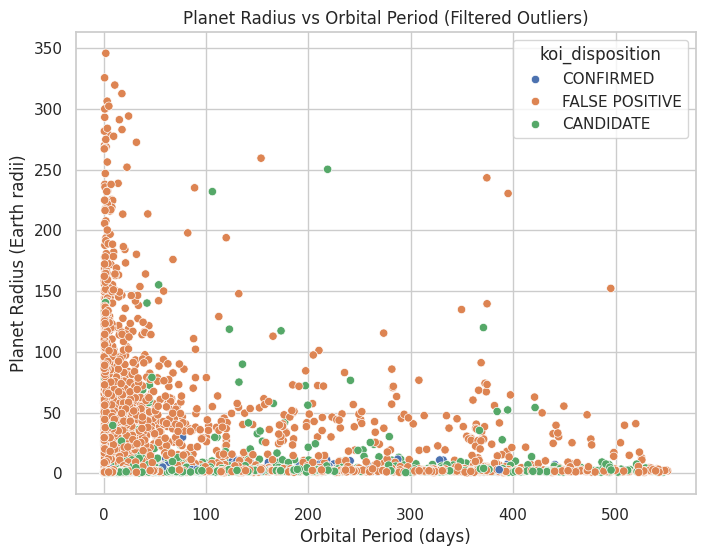

In [28]:
# Set thresholds to filter out extreme outliers
period_upper = df_final['koi_period'].quantile(0.99)
radius_upper = df_final['koi_prad'].quantile(0.99)

# Filter the dataset
df_filtered = df_final[(df_final['koi_period'] <= period_upper) &
                       (df_final['koi_prad'] <= radius_upper)]


plt.figure(figsize=(8,6))
sns.scatterplot(x='koi_period', y='koi_prad', hue='koi_disposition', data=df_filtered)
plt.title("Planet Radius vs Orbital Period (Filtered Outliers)")
plt.xlabel("Orbital Period (days)")
plt.ylabel("Planet Radius (Earth radii)")
plt.show()



**Violin Plot**

Shows distribution of numeric columns by koi_disposition

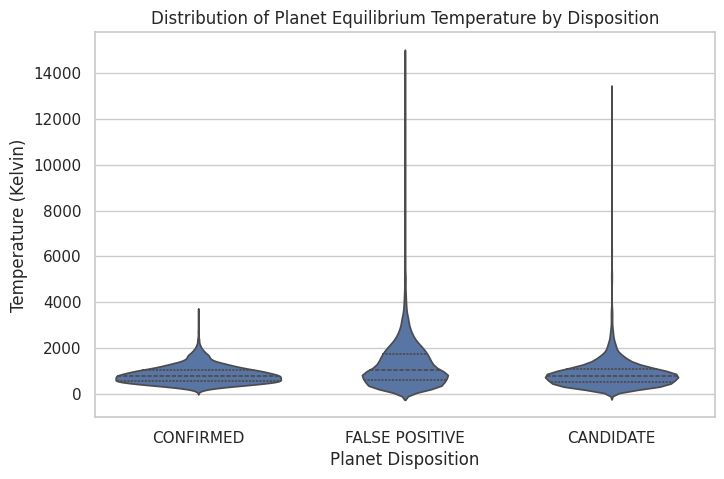

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.violinplot(
    x='koi_disposition',
    y='koi_teq',
    data=df_final,
    inner='quartile',
    hue=None,
    palette=None
)
plt.title("Distribution of Planet Equilibrium Temperature by Disposition")
plt.xlabel("Planet Disposition")
plt.ylabel("Temperature (Kelvin)")
plt.show()


**Habitable Zone–Style Plot**

Shows which planets fall into “potentially habitable” temperature ranges.

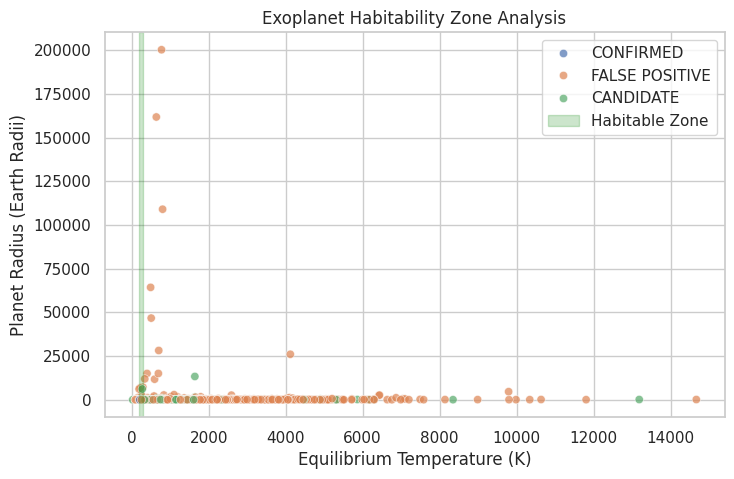

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='koi_teq',
    y='koi_prad',
    hue='koi_disposition',
    data=df_final,
    alpha=0.7
)

plt.axvspan(180, 300, color='green', alpha=0.2, label='Habitable Zone')
plt.xlabel("Equilibrium Temperature (K)")
plt.ylabel("Planet Radius (Earth Radii)")
plt.title("Exoplanet Habitability Zone Analysis")
plt.legend()
plt.show()

**Log-Scale Orbital Period Plot**

Shows wide-ranging orbital periods clearly.

Confirmed exoplanets were visualized separately due to their smaller frequency.

Since planetary orbital periods and radii span several orders of magnitude, a logarithmic scale was applied to both axes.





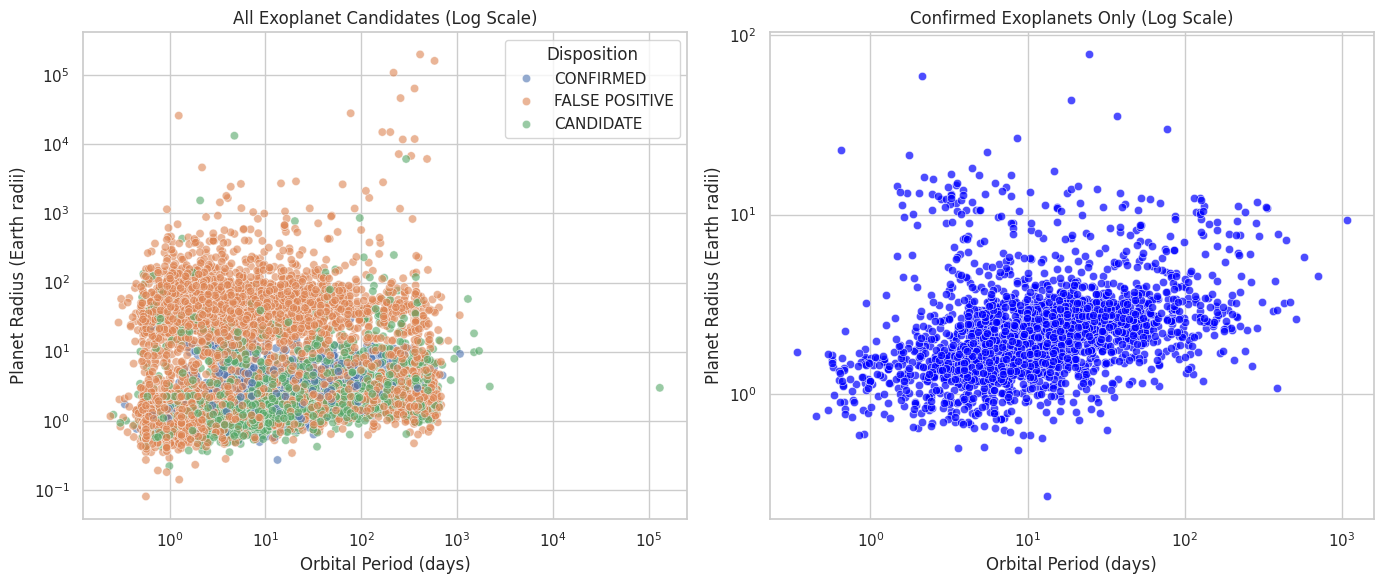

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# -------- Plot 1: All Dispositions --------
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df_final,
    x='koi_period',
    y='koi_prad',
    hue='koi_disposition',
    alpha=0.6
)
plt.xscale('log')
plt.yscale('log')
plt.title("All Exoplanet Candidates (Log Scale)")
plt.xlabel("Orbital Period (days)")
plt.ylabel("Planet Radius (Earth radii)")
plt.legend(title="Disposition")

# -------- Plot 2: Confirmed Only --------
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=df_final[df_final['koi_disposition'] == 'CONFIRMED'],
    x='koi_period',
    y='koi_prad',
    color='blue',
    alpha=0.7
)
plt.xscale('log')
plt.yscale('log')
plt.title("Confirmed Exoplanets Only (Log Scale)")
plt.xlabel("Orbital Period (days)")
plt.ylabel("Planet Radius (Earth radii)")

plt.tight_layout()
plt.show()


**Density Plot**

This density plot visualizes the distribution of planet temperatures (koi_teq) for different types of exoplanets based on their disposition (CONFIRMED vs FALSE POSITIVE).

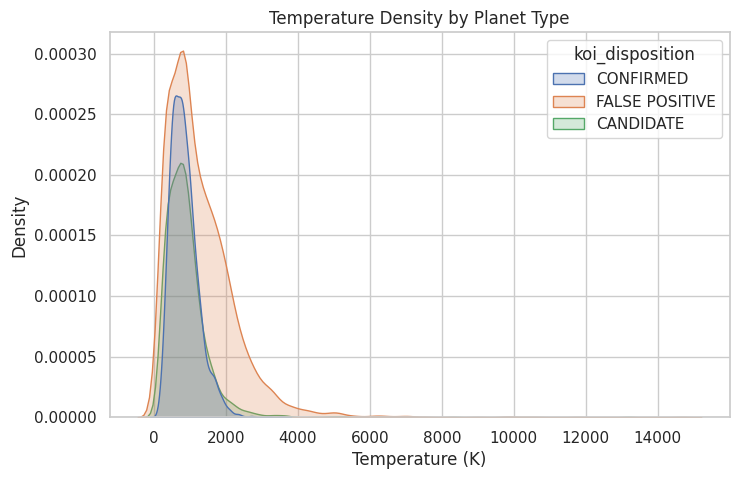

In [32]:
plt.figure(figsize=(8,5))
sns.kdeplot(
    data=df_final,
    x="koi_teq",
    hue="koi_disposition",
    fill=True
)
plt.title("Temperature Density by Planet Type")
plt.xlabel("Temperature (K)")
plt.show()

**Correlation Heatmap**

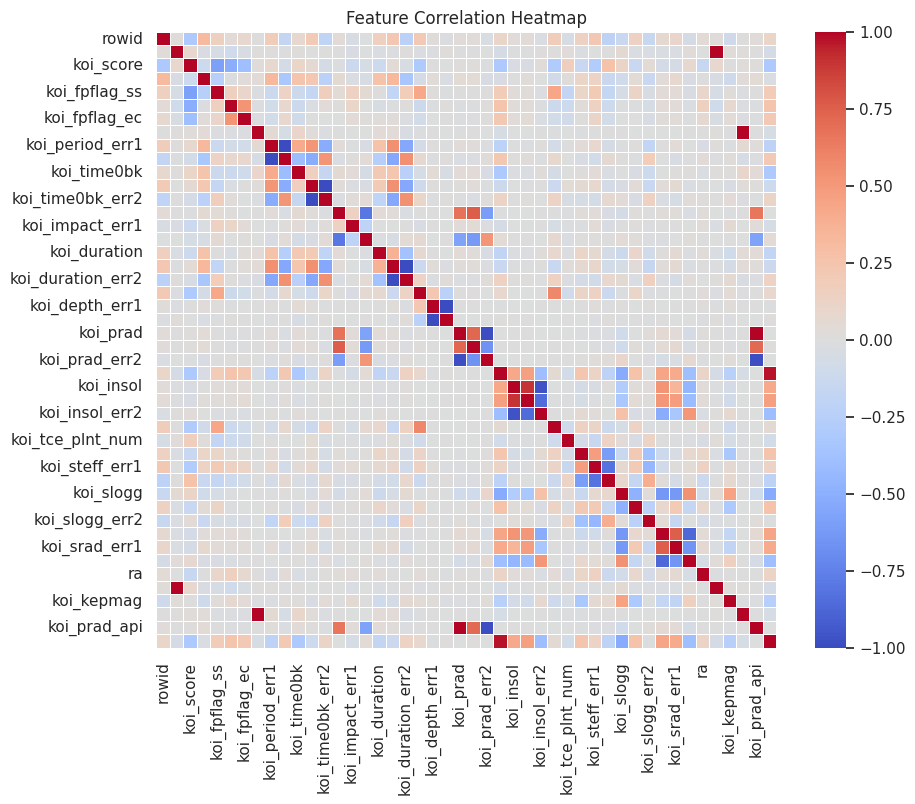

In [33]:
plt.figure(figsize=(10,8))
corr = df_final.select_dtypes(include=['float64','int64']).corr()
sns.heatmap(corr, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

**Stellar Temperature Distribution**

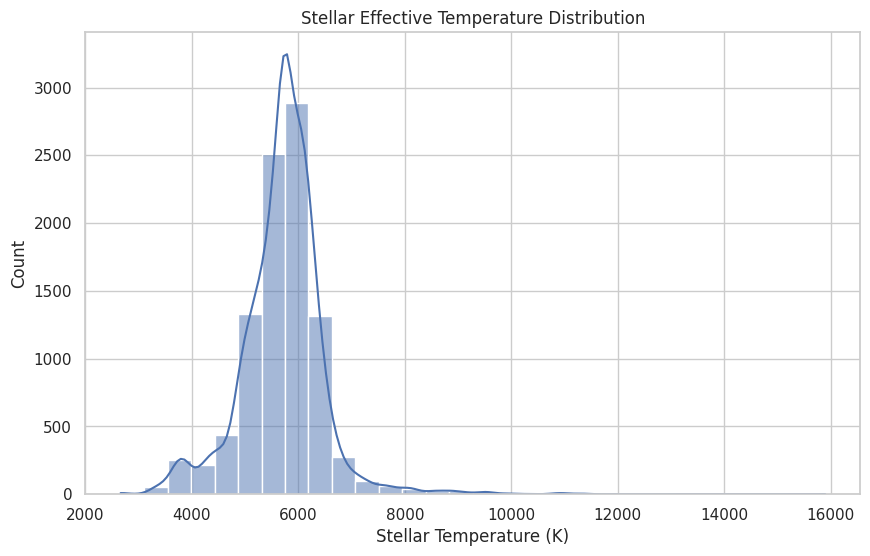

In [34]:
plt.figure()
sns.histplot(df_final['koi_steff'], bins=30, kde=True)
plt.title("Stellar Effective Temperature Distribution")
plt.xlabel("Stellar Temperature (K)")
plt.ylabel("Count")
plt.show()

**Boxplot of Planet Radius by Disposition**

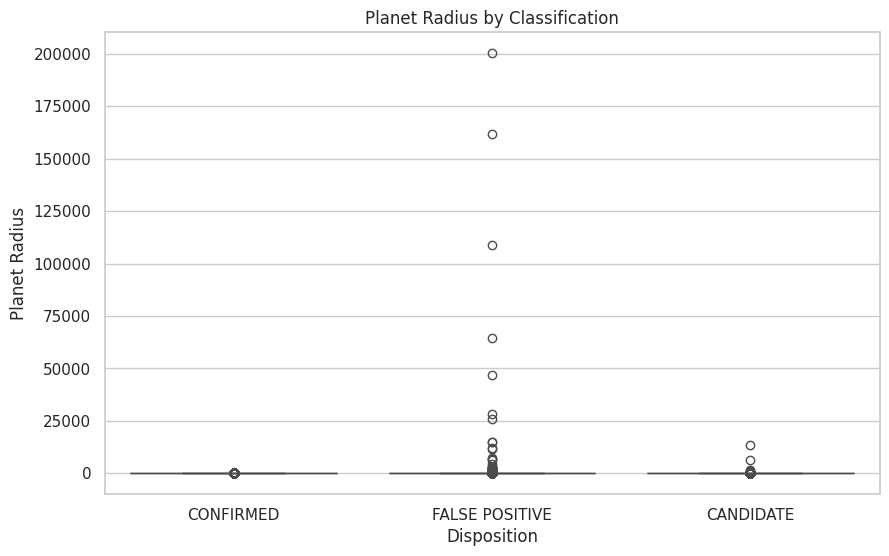

In [35]:
plt.figure()
sns.boxplot(x='koi_disposition', y='koi_prad', data=df_final)
plt.title("Planet Radius by Classification")
plt.xlabel("Disposition")
plt.ylabel("Planet Radius")
plt.show()


Pairplot

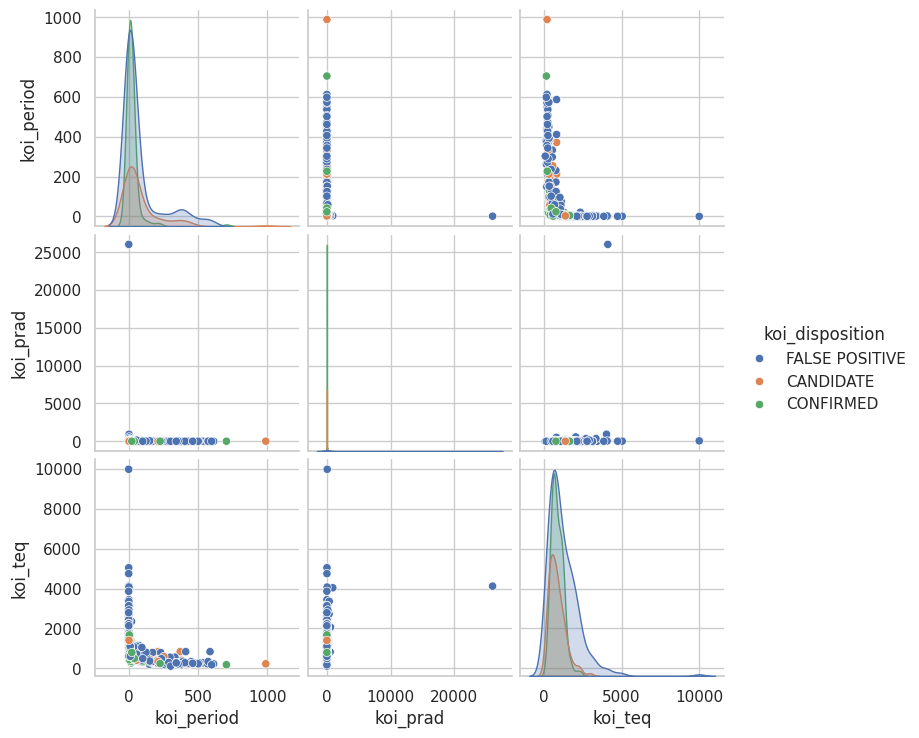

In [36]:
sample_df = df_final[['koi_period', 'koi_prad', 'koi_teq', 'koi_disposition']].sample(500)
sns.pairplot(sample_df, hue='koi_disposition')
plt.show()

Planet Score Distribution

Plots koi_score (model’s likelihood for planet candidacy) as a histogram or violin, giving a sense of confidence distribution across candidates.

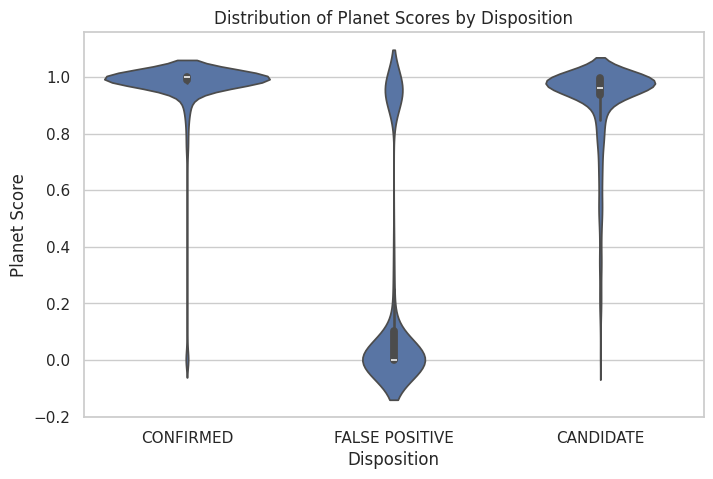

In [37]:
plt.figure(figsize=(8,5))
sns.violinplot(x='koi_disposition', y='koi_score', data=df_final)
plt.title("Distribution of Planet Scores by Disposition")
plt.xlabel("Disposition")
plt.ylabel("Planet Score")
plt.show()

Scatter of Stellar Radius vs Stellar Surface Gravity

Plots koi_srad vs koi_slogg to explore stellar characteristics independent of the planets.

Useful for seeing clusters of star types hosting different planet types.

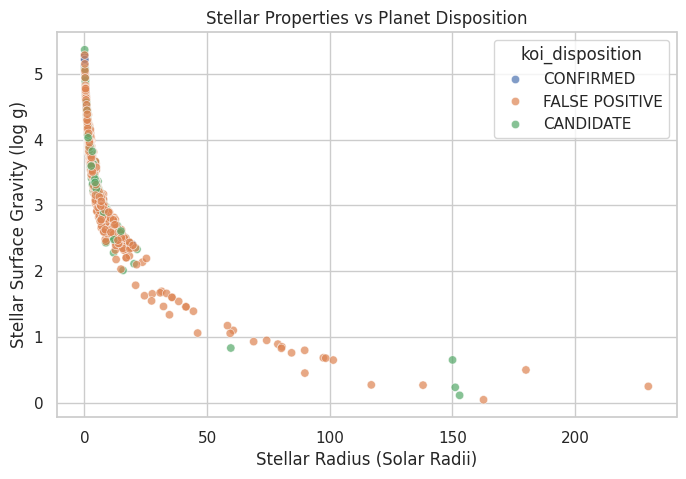

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='koi_srad',
    y='koi_slogg',
    hue='koi_disposition',
    data=df_final,
    alpha=0.7
)
plt.xlabel("Stellar Radius (Solar Radii)")
plt.ylabel("Stellar Surface Gravity (log g)")
plt.title("Stellar Properties vs Planet Disposition")
plt.show()

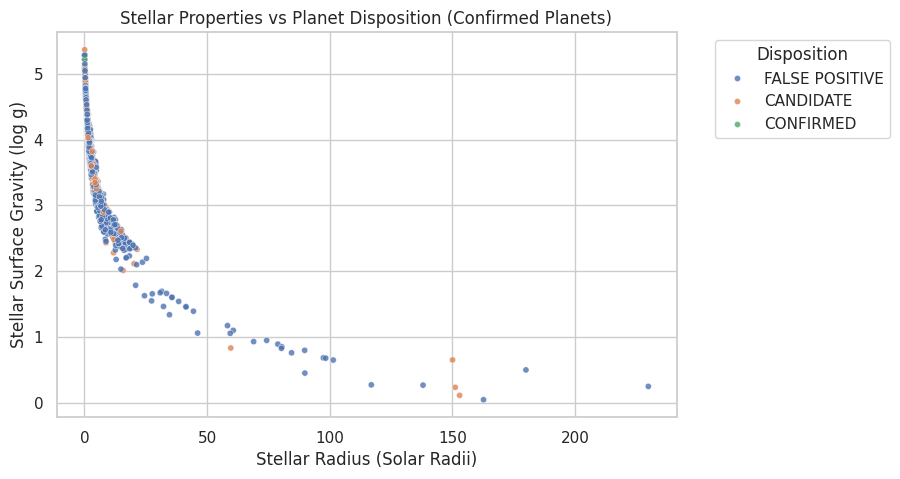

In [39]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='koi_srad',
    y='koi_slogg',
    hue='koi_disposition',
    hue_order=['FALSE POSITIVE', 'CANDIDATE', 'CONFIRMED'],
    data=df_final,
    alpha=0.8,
    s=20
)

plt.xlabel("Stellar Radius (Solar Radii)")
plt.ylabel("Stellar Surface Gravity (log g)")
plt.title("Stellar Properties vs Planet Disposition (Confirmed Planets)")
plt.legend(title="Disposition", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Feature Importance Plot**

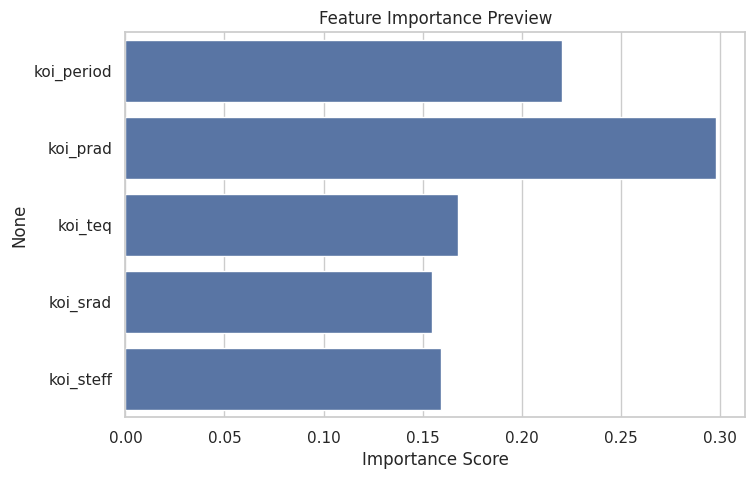

In [40]:
from sklearn.ensemble import RandomForestClassifier

X = df_final[['koi_period','koi_prad','koi_teq','koi_srad','koi_steff']]
y = df_final['koi_disposition']

model = RandomForestClassifier()
model.fit(X, y)

importances = model.feature_importances_

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=X.columns)
plt.title("Feature Importance Preview")
plt.xlabel("Importance Score")
plt.show()

## **PCA**

In [41]:
import pandas as pd


df = df_final.copy()

# Remove non-quantitative columns
df_quant = df.drop(columns=['kepid', 'kepoi_name', 'koi_disposition'], errors='ignore')

df_quant.head()


,rowid,kepler_name,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,koi_time0bk_err2,koi_impact,koi_impact_err1,koi_impact_err2,koi_duration,koi_duration_err1,koi_duration_err2,koi_depth,koi_depth_err1,koi_depth_err2,koi_prad,koi_prad_err1,koi_prad_err2,koi_teq,koi_insol,koi_insol_err1,koi_insol_err2,koi_model_snr,koi_tce_plnt_num,koi_steff,koi_steff_err1,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag,kepoi_name_api,koi_disposition_api,koi_period_api,koi_prad_api,koi_teq_api
0,1,Kepler-227 b,CANDIDATE,1.000,0,0,0,0,9.488036,2.775000e-05,-2.775000e-05,170.538750,0.002160,-0.002160,0.146,0.318,-0.146,2.95750,0.08190,-0.08190,615.8,19.5,-19.5,2.26,0.26,-0.15,793.0,93.59,29.45,-16.65,35.8,1.0,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347,K00752.01,CONFIRMED,9.488036,2.26,793.0
1,2,Kepler-227 c,CANDIDATE,0.969,0,0,0,0,54.418383,2.479000e-04,-2.479000e-04,162.513840,0.003520,-0.003520,0.586,0.059,-0.443,4.50700,0.11600,-0.11600,874.8,35.5,-35.5,2.83,0.32,-0.19,443.0,9.11,2.87,-1.62,25.8,2.0,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347,K00752.01,CONFIRMED,9.488036,2.26,793.0
2,3,Unknown,FALSE POSITIVE,0.000,0,1,0,0,19.899140,1.494000e-05,-1.494000e-05,175.850252,0.000581,-0.000581,0.969,5.126,-0.077,1.78220,0.03410,-0.03410,10829.0,171.0,-171.0,14.60,3.92,-1.31,638.0,39.30,31.04,-10.49,76.3,1.0,5853.0,158.0,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436,K00753.01,FALSE POSITIVE,19.899140,14.60,638.0
3,4,Unknown,FALSE POSITIVE,0.000,0,1,0,0,1.736952,2.630000e-07,-2.630000e-07,170.307565,0.000115,-0.000115,1.276,0.115,-0.092,2.40641,0.00537,-0.00537,8079.2,12.8,-12.8,33.46,8.50,-2.83,1395.0,891.96,668.95,-230.35,505.6,1.0,5805.0,157.0,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597,K00754.01,FALSE POSITIVE,1.736952,33.46,1395.0
4,5,Kepler-664 b,CANDIDATE,1.000,0,0,0,0,2.525592,3.761000e-06,-3.761000e-06,171.595550,0.001130,-0.001130,0.701,0.235,-0.478,1.65450,0.04200,-0.04200,603.3,16.9,-16.9,2.75,0.88,-0.35,1406.0,926.16,874.33,-314.24,40.9,1.0,6031.0,169.0,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509,K00755.01,CONFIRMED,2.525592,2.75,1406.0


In [42]:
df_quant = df.select_dtypes(include='number')


**Normalize: Standard Scalar**

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_quant)

X_scaled[:5]


array([[-1.73186972,  1.17092219,  0.94392432, -0.48149689, -0.5490005 ,
        -0.49201415, -0.36933297, -0.04958762, -0.25091819,  0.25091819,
         0.06413124, -0.33148259,  0.33148259, -0.17684874, -0.16930091,
         0.14945722, -0.41168563, -0.37853445,  0.37853445, -0.27588957,
        -0.02459791,  0.02459791, -0.03207204, -0.04364293,  0.02701973,
        -0.33621153, -0.04725672, -0.06647369,  0.04479433, -0.27518184,
        -0.35908646, -0.32270457, -1.38931087,  1.13257709,  0.35762874,
        -0.41734618,  0.54779842, -0.12874572, -0.27538418,  0.15112447,
        -0.02642094,  1.20276381,  0.78131914, -0.04774115, -0.03143262,
        -0.34447457],
       [-1.73150751,  1.17092219,  0.8780535 , -0.48149689, -0.5490005 ,
        -0.49201415, -0.36933297, -0.01592372, -0.22357225,  0.22357225,
        -0.05402914, -0.27124764,  0.27124764, -0.04289623, -0.19744549,
        -0.09400859, -0.17224066, -0.32649188,  0.32649188, -0.27268357,
        -0.02061152,  0.02061

Before applying PCA, all non-numeric columns were removed to ensure that only quantitative variables were included, as PCA requires numerical input.

In [44]:
df_quant.shape


(9564, 46)

In [45]:
from sklearn.decomposition import PCA

pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

print("Explained variance ratio (2D):", pca2.explained_variance_ratio_)
print("Total variance retained (2D):", sum(pca2.explained_variance_ratio_))


Explained variance ratio (2D): [0.12208634 0.11121409]
Total variance retained (2D): 0.23330043232505027


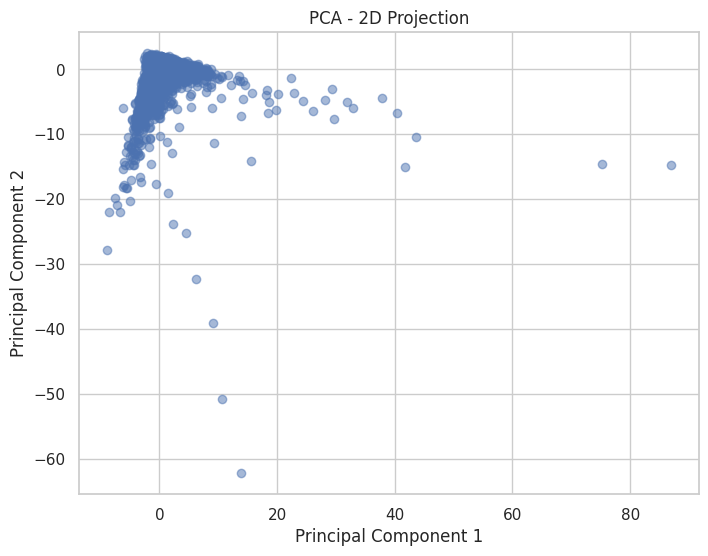

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca2[:,0], X_pca2[:,1], alpha=0.5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - 2D Projection")
plt.show()


In [47]:
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

print("Explained variance ratio (3D):", pca3.explained_variance_ratio_)
print("Total variance retained (3D):", sum(pca3.explained_variance_ratio_))


Explained variance ratio (3D): [0.12208634 0.11121409 0.09864404]
Total variance retained (3D): 0.3319444697035696


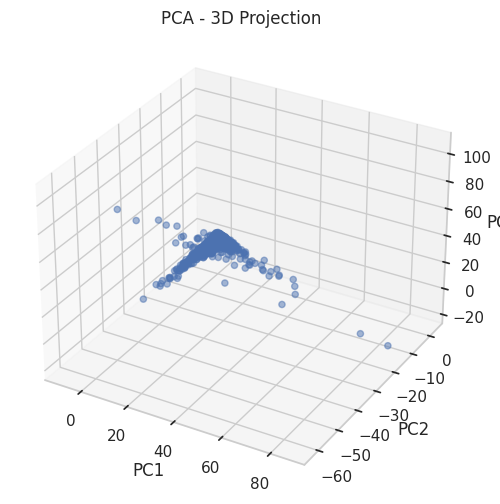

In [48]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], alpha=0.5)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA - 3D Projection")

plt.show()


In [49]:
pca_full = PCA()
pca_full.fit(X_scaled)

import numpy as np

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

print(cumulative_variance)


[0.12208634 0.23330043 0.33194447 0.40942669 0.45737221 0.50335622
 0.54675973 0.58853512 0.62753114 0.66422772 0.69342427 0.71965787
 0.74373452 0.76577217 0.7870425  0.80746774 0.82621004 0.84439848
 0.86128407 0.87721857 0.89112306 0.90452696 0.91688337 0.92873581
 0.93957234 0.94906489 0.95807616 0.96566068 0.97264755 0.97905883
 0.98422033 0.98861209 0.991953   0.9949396  0.99695545 0.99868615
 0.99921677 0.99958615 0.99982946 0.99996588 0.99999386 1.
 1.         1.         1.         1.        ]


In [50]:
np.argmax(cumulative_variance >= 0.95) + 1


np.int64(27)

In [51]:
print("Top 3 Eigenvalues:")
print(pca_full.explained_variance_[:3])


Top 3 Eigenvalues:
[5.6165589  5.11638321 4.53810022]


In [52]:
sum(pca2.explained_variance_ratio_)



np.float64(0.23330043232505027)

In [53]:
sum(pca3.explained_variance_ratio_)

np.float64(0.3319444697035696)

In [54]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(df_quant.columns))],
    index=df_quant.columns
)

loadings[['PC1','PC2','PC3']].sort_values(by='PC1', ascending=False).head()

,PC1,PC2,PC3
koi_teq,0.343250,0.029953,-0.038972
koi_teq_api,0.341038,0.023111,-0.041749
koi_srad,0.310122,-0.093383,-0.055573
koi_insol_err1,0.294573,-0.054001,-0.068942
koi_insol,0.288086,-0.051834,-0.067215


In [55]:
labels_original = df['koi_disposition']

# Keep only numeric columns
df_quant = df.select_dtypes(include='number')

df_quant.shape

(9564, 46)

In [56]:
import warnings
warnings.filterwarnings("ignore")
pd.DataFrame(X_scaled, columns=df_quant.columns).head()

,rowid,kepid,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,koi_time0bk_err2,koi_impact,koi_impact_err1,koi_impact_err2,koi_duration,koi_duration_err1,koi_duration_err2,koi_depth,koi_depth_err1,koi_depth_err2,koi_prad,koi_prad_err1,koi_prad_err2,koi_teq,koi_insol,koi_insol_err1,koi_insol_err2,koi_model_snr,koi_tce_plnt_num,koi_steff,koi_steff_err1,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag,koi_period_api,koi_prad_api,koi_teq_api
0,-1.731870,1.170922,0.943924,-0.481497,-0.549001,-0.492014,-0.369333,-0.049588,-0.250918,0.250918,0.064131,-0.331483,0.331483,-0.176849,-0.169301,0.149457,-0.411686,-0.378534,0.378534,-0.275890,-0.024598,0.024598,-0.032072,-0.043643,0.027020,-0.336212,-0.047257,-0.066474,0.044794,-0.275182,-0.359086,-0.322705,-1.389311,1.132577,0.357629,-0.417346,0.547798,-0.128746,-0.275384,0.151124,-0.026421,1.202764,0.781319,-0.047741,-0.031433,-0.344475
1,-1.731508,1.170922,0.878053,-0.481497,-0.549001,-0.492014,-0.369333,-0.015924,-0.223572,0.223572,-0.054029,-0.271248,0.271248,-0.042896,-0.197445,-0.094009,-0.172241,-0.326492,0.326492,-0.272684,-0.020612,0.020612,-0.031883,-0.043487,0.026986,-0.752249,-0.047797,-0.066965,0.044967,-0.287973,1.169989,-0.322705,-1.389311,1.132577,0.357629,-0.417346,0.547798,-0.128746,-0.275384,0.151124,-0.026421,1.202764,0.781319,-0.047741,-0.031433,-0.344475
2,-1.731145,1.176212,-1.180941,-0.481497,1.821492,-0.492014,-0.369333,-0.041787,-0.252509,0.252509,0.142339,-0.401417,0.401417,0.073703,0.353167,0.206020,-0.593305,-0.451486,0.451486,-0.149467,0.013148,-0.013148,-0.027984,-0.034103,0.026029,-0.520457,-0.047604,-0.066444,0.044865,-0.223379,-0.359086,0.186540,0.288726,-0.205781,0.538807,-0.571192,-0.409420,-0.138561,-0.134463,0.143088,1.037397,1.200675,0.845565,-0.039939,-0.027337,-0.529387
3,-1.730783,1.190143,-1.180941,-0.481497,1.821492,-0.492014,-0.369333,-0.055395,-0.254332,0.254332,0.060727,-0.422056,0.422056,0.167166,-0.191360,0.193724,-0.496846,-0.495333,0.495333,-0.183505,-0.026267,0.026267,-0.021736,-0.022164,0.024730,0.379374,-0.042156,-0.054656,0.042335,0.325727,-0.359086,0.125124,0.266933,-0.177605,0.585866,-0.501961,-0.313698,-0.151371,-0.169693,0.148288,-1.369071,1.242630,0.961785,-0.053550,-0.021078,0.373701
4,-1.730421,1.192441,0.943924,-0.481497,-0.549001,-0.492014,-0.369333,-0.054804,-0.253898,0.253898,0.079692,-0.377102,0.377102,-0.007886,-0.178320,-0.122700,-0.613039,-0.439429,0.439429,-0.276044,-0.025246,0.025246,-0.031910,-0.042027,0.026849,0.392449,-0.041937,-0.050861,0.041369,-0.268659,-0.359086,0.414293,0.528445,-0.698861,0.289393,-0.371192,-0.816238,-0.108949,-0.023267,0.117087,-0.693454,1.226243,0.898261,-0.052959,-0.031270,0.386824


## **Kmeans**

In [57]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

for k, score in zip(k_values, silhouette_scores):
    print(f"k = {k}, Silhouette Score = {score:.4f}")

k = 2, Silhouette Score = 0.3745
k = 3, Silhouette Score = 0.3757
k = 4, Silhouette Score = 0.1427
k = 5, Silhouette Score = 0.1496
k = 6, Silhouette Score = 0.1729
k = 7, Silhouette Score = 0.1759
k = 8, Silhouette Score = 0.1753
k = 9, Silhouette Score = 0.1027
k = 10, Silhouette Score = 0.1602


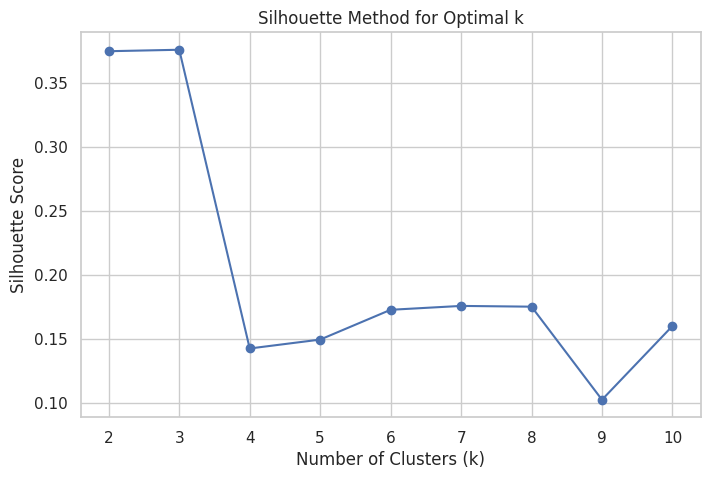

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method for Optimal k")
plt.show()

In [59]:
k = 2

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [60]:
np.bincount(clusters)

array([ 859, 8705])

In [61]:
centroids_pca = pca3.transform(kmeans.cluster_centers_)

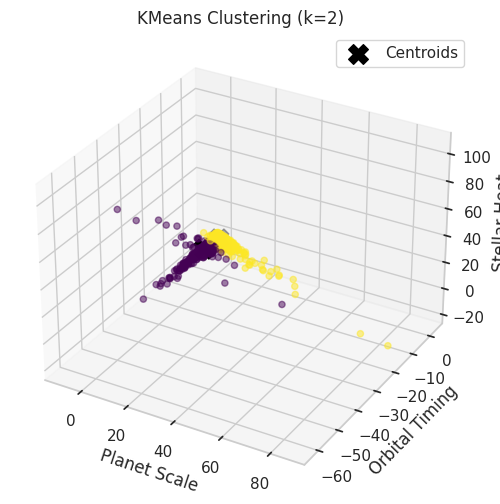

In [62]:
from mpl_toolkits.mplot3d import Axes3D

centroids_pca = pca3.transform(kmeans.cluster_centers_)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca3[:,0],
    X_pca3[:,1],
    X_pca3[:,2],
    c=clusters,
    cmap='viridis',
    alpha=0.5
)

ax.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    centroids_pca[:,2],
    c='black',
    s=200,
    marker='X',
    label='Centroids'
)

ax.set_title(f"KMeans Clustering (k={k})")
ax.set_xlabel("Planet Scale")
ax.set_ylabel("Orbital Timing")
ax.set_zlabel("Stellar Heat")

plt.legend()
plt.show()

In [63]:
import pandas as pd

comparison = pd.DataFrame({
    "Cluster": clusters,
    "Original_Label": df['koi_disposition']
})

pd.crosstab(comparison["Cluster"], comparison["Original_Label"])

Original_Label,CANDIDATE,CONFIRMED,FALSE POSITIVE
Cluster,,,
0,180,6,673
1,2068,2287,4350


In [64]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [65]:
np.bincount(clusters)

array([8678,   25,  861])

In [66]:
centroids_pca = pca3.transform(kmeans.cluster_centers_)

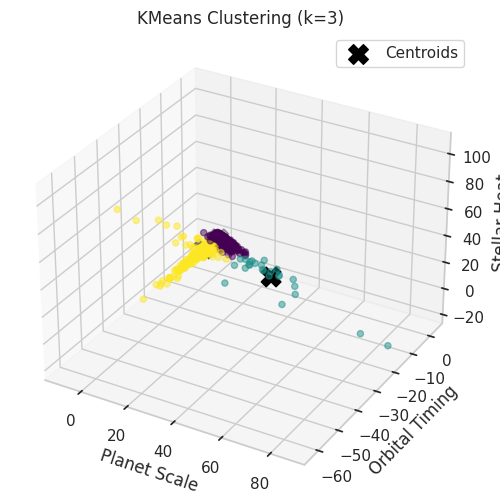

In [67]:
from mpl_toolkits.mplot3d import Axes3D

centroids_pca = pca3.transform(kmeans.cluster_centers_)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca3[:,0],
    X_pca3[:,1],
    X_pca3[:,2],
    c=clusters,
    cmap='viridis',
    alpha=0.5
)

ax.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    centroids_pca[:,2],
    c='black',
    s=200,
    marker='X',
    label='Centroids'
)

ax.set_title(f"KMeans Clustering (k={k})")
ax.set_xlabel("Planet Scale")
ax.set_ylabel("Orbital Timing")
ax.set_zlabel("Stellar Heat")

plt.legend()
plt.show()

In [68]:
import pandas as pd

comparison = pd.DataFrame({
    "Cluster": clusters,
    "Original_Label": df['koi_disposition']
})

pd.crosstab(comparison["Cluster"], comparison["Original_Label"])

Original_Label,CANDIDATE,CONFIRMED,FALSE POSITIVE
Cluster,,,
0,2063,2287,4328
1,4,0,21
2,181,6,674


In [69]:
k = 4

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [70]:
np.bincount(clusters)

array([  25, 5882,    5, 3652])

In [71]:
centroids_pca = pca3.transform(kmeans.cluster_centers_)

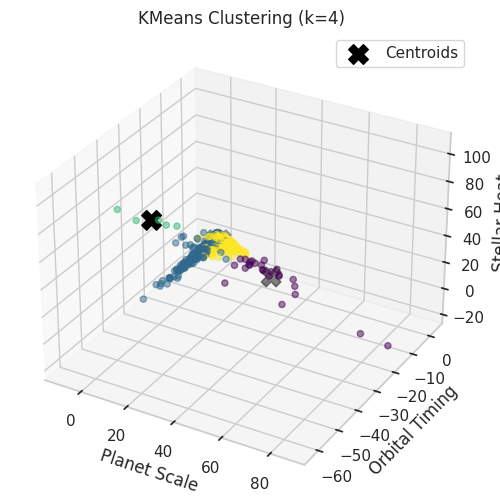

In [72]:
from mpl_toolkits.mplot3d import Axes3D

centroids_pca = pca3.transform(kmeans.cluster_centers_)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca3[:,0],
    X_pca3[:,1],
    X_pca3[:,2],
    c=clusters,
    cmap='viridis',
    alpha=0.5
)

ax.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    centroids_pca[:,2],
    c='black',
    s=200,
    marker='X',
    label='Centroids'
)

ax.set_title(f"KMeans Clustering (k={k})")
ax.set_xlabel("Planet Scale")
ax.set_ylabel("Orbital Timing")
ax.set_zlabel("Stellar Heat")

plt.legend()
plt.show()

In [73]:
import pandas as pd

comparison = pd.DataFrame({
    "Cluster": clusters,
    "Original_Label": df['koi_disposition']
})

pd.crosstab(comparison["Cluster"], comparison["Original_Label"])

Original_Label,CANDIDATE,CONFIRMED,FALSE POSITIVE
Cluster,,,
0,4,0,21
1,2132,2266,1484
2,0,0,5
3,112,27,3513


In [74]:
print(df.columns)

Index(['rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_disposition',
       'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss',
       'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1',
       'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1',
       'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2',
       'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth',
       'koi_depth_err1', 'koi_depth_err2', 'koi_prad', 'koi_prad_err1',
       'koi_prad_err2', 'koi_teq', 'koi_insol', 'koi_insol_err1',
       'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num', 'koi_steff',
       'koi_steff_err1', 'koi_steff_err2', 'koi_slogg', 'koi_slogg_err1',
       'koi_slogg_err2', 'koi_srad', 'koi_srad_err1', 'koi_srad_err2', 'ra',
       'dec', 'koi_kepmag', 'kepoi_name_api', 'koi_disposition_api',
       'koi_period_api', 'koi_prad_api', 'koi_teq_api'],
      dtype='object')


In [75]:
cols_to_show = ['koi_period', 'koi_prad', 'koi_disposition']


check_df = df[cols_to_show].copy()


check_df['Cluster'] = clusters

print(check_df.head(10))

   koi_period  koi_prad koi_disposition  Cluster
0    9.488036      2.26       CONFIRMED        1
1   54.418383      2.83       CONFIRMED        1
2   19.899140     14.60  FALSE POSITIVE        3
3    1.736952     33.46  FALSE POSITIVE        3
4    2.525592      2.75       CONFIRMED        1
5   11.094321      3.90       CONFIRMED        1
6    4.134435      2.77       CONFIRMED        1
7    2.566589      1.59       CONFIRMED        1
8    7.361790     39.21  FALSE POSITIVE        3
9   16.068647      5.76       CONFIRMED        1


Although the Silhouette method suggested that k=3 provided the strongest separation, the resulting clusters did not perfectly align with the original exoplanet disposition labels. This suggests that while physical characteristics influence classification, they are not solely responsible for determining confirmed versus false-positive status.

Increasing k beyond 3 resulted in smaller artificial clusters, consistent with declining silhouette scores.

## **Hierarchical Clustering**

In [76]:

pca_transformed = pca_full.transform(X_scaled)

In [77]:

your_data = pca_transformed[:, :3]

In [78]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram


Z = linkage(your_data, method='ward')

# Extract the 3 clusters
hier_clusters = fcluster(Z, t=3, criterion='maxclust')

In [79]:
import numpy as np
print(np.bincount(hier_clusters))

[   0    5  507 9052]


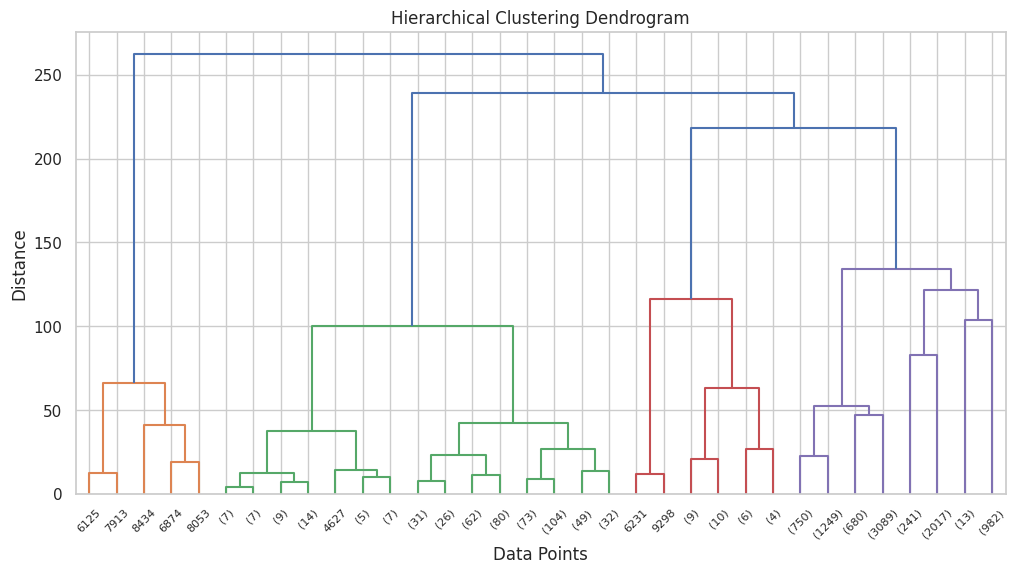

In [80]:
plt.figure(figsize=(12,6))
dendrogram(
    Z,
    truncate_mode='level',
    p=5
)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

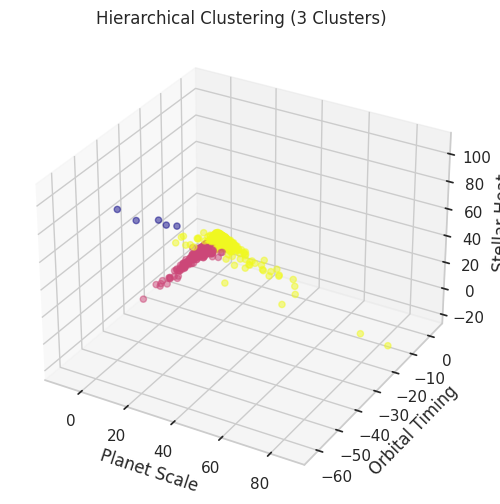

In [81]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca3[:,0],
    X_pca3[:,1],
    X_pca3[:,2],
    c=hier_clusters,
    cmap='plasma',
    alpha=0.5
)

ax.set_title("Hierarchical Clustering (3 Clusters)")
ax.set_xlabel("Planet Scale")
ax.set_ylabel("Orbital Timing")
ax.set_zlabel("Stellar Heat")

plt.show()

In [82]:
import pandas as pd

comparison_hier = pd.DataFrame({
    "Cluster": hier_clusters,
    "Original_Label": df['koi_disposition']
})

pd.crosstab(comparison_hier["Cluster"], comparison_hier["Original_Label"])

Original_Label,CANDIDATE,CONFIRMED,FALSE POSITIVE
Cluster,,,
1,0,0,5
2,105,1,401
3,2143,2292,4617


In [83]:

from sklearn.cluster import DBSCAN


dbscan = DBSCAN(eps=1.0, min_samples=10)

# 2. Fit and predict on your PCA data
db_clusters = dbscan.fit_predict(pca_transformed[:, :3])

# 3. Check the results
import numpy as np
print("Cluster counts (-1 is Noise):")
print(pd.Series(db_clusters).value_counts())

Cluster counts (-1 is Noise):
 0    9420
-1     134
 1      10
Name: count, dtype: int64


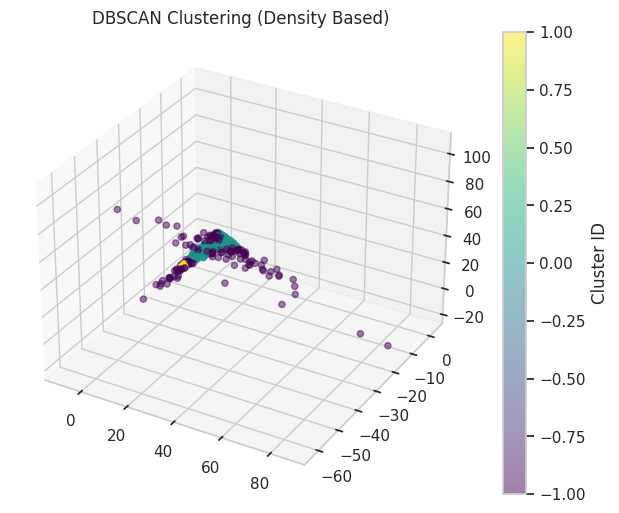

In [84]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')


scatter = ax.scatter(pca_transformed[:, 0],
                    pca_transformed[:, 1],
                    pca_transformed[:, 2],
                    c=db_clusters, cmap='viridis', alpha=0.5)

ax.set_title('DBSCAN Clustering (Density Based)')
plt.colorbar(scatter, label='Cluster ID')
plt.show()

In [85]:
import pandas as pd

db_counts = pd.Series(db_clusters).value_counts()

print("--- DBSCAN Results ---")
print(f"Number of clusters found: {len(db_counts[db_counts.index != -1])}")
print(f"Number of Noise points (-1): {db_counts.get(-1, 0)}")
print(db_counts)

--- DBSCAN Results ---
Number of clusters found: 2
Number of Noise points (-1): 134
 0    9420
-1     134
 1      10
Name: count, dtype: int64


In [86]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import AgglomerativeClustering

hierarchical_model = AgglomerativeClustering(n_clusters=3)

hierarchical_labels = hierarchical_model.fit_predict(pca_transformed[:, :3])

In [87]:
import warnings
warnings.filterwarnings('ignore')
final_comparison = df[['koi_period', 'koi_prad', 'koi_steff', 'koi_disposition']].copy()


final_comparison['KMeans_Cluster'] = clusters
final_comparison['hier_clusters'] = hierarchical_labels
final_comparison['DBSCAN_Cluster'] = db_clusters

In [88]:
print(final_comparison.head(15))

    koi_period  koi_prad  koi_steff koi_disposition  KMeans_Cluster  \
0     9.488036      2.26     5455.0       CONFIRMED               1   
1    54.418383      2.83     5455.0       CONFIRMED               1   
2    19.899140     14.60     5853.0  FALSE POSITIVE               3   
3     1.736952     33.46     5805.0  FALSE POSITIVE               3   
4     2.525592      2.75     6031.0       CONFIRMED               1   
5    11.094321      3.90     6046.0       CONFIRMED               1   
6     4.134435      2.77     6046.0       CONFIRMED               1   
7     2.566589      1.59     6046.0       CONFIRMED               1   
8     7.361790     39.21     6227.0  FALSE POSITIVE               3   
9    16.068647      5.76     5031.0       CONFIRMED               1   
10    2.470613     13.04     5820.0       CONFIRMED               1   
11    2.204735     16.10     6440.0       CONFIRMED               3   
12    3.522498     14.59     6225.0       CONFIRMED               1   
13    

In [89]:
import warnings
warnings.filterwarnings('ignore')
final_comparison = df[['koi_period', 'koi_prad', 'koi_steff', 'koi_disposition']].copy()


final_comparison['Cluster'] = clusters
final_comparison['hier_clusters'] = hierarchical_labels
final_comparison['db_Clusters'] = db_clusters

In [90]:
print(final_comparison.head(15))

    koi_period  koi_prad  koi_steff koi_disposition  Cluster  hier_clusters  \
0     9.488036      2.26     5455.0       CONFIRMED        1              0   
1    54.418383      2.83     5455.0       CONFIRMED        1              0   
2    19.899140     14.60     5853.0  FALSE POSITIVE        3              0   
3     1.736952     33.46     5805.0  FALSE POSITIVE        3              0   
4     2.525592      2.75     6031.0       CONFIRMED        1              0   
5    11.094321      3.90     6046.0       CONFIRMED        1              0   
6     4.134435      2.77     6046.0       CONFIRMED        1              0   
7     2.566589      1.59     6046.0       CONFIRMED        1              0   
8     7.361790     39.21     6227.0  FALSE POSITIVE        3              0   
9    16.068647      5.76     5031.0       CONFIRMED        1              0   
10    2.470613     13.04     5820.0       CONFIRMED        1              0   
11    2.204735     16.10     6440.0       CONFIRMED 

**Comparison**

The clustering analysis revealed a high degree of physical homogeneity within the exoplanet dataset. K-Means forced the data into three artificial segments, while Hierarchical Clustering isolated extreme physical outliers (Clusters 1 and 2) but kept the core intact. DBSCAN provided the most definitive insight, identifying 98.5% of the data as a single dense cluster (Cluster 0) and classifying the remaining points as noise. This consistent behavior across all three algorithms confirms that 'Confirmed' planets and 'False Positives' overlap significantly in physical feature space, implying that classification depends on factors beyond the basic physical measurements provided.

Physical Homogeneity: The most significant finding is that the vast majority of exoplanet candidates ($9,000+$ points) are physically indistinguishable from one another in the standardized PCA space.

Label Disconnect: Although the Silhouette method suggested $k=3$ as a mathematically strong split, those clusters do not align with the original Disposition labels (Confirmed vs. False Positive).

The "Powerful Conclusion": astronomical classification is not determined by physical measurements alone. This suggests that the final status of a planet relies on non-physical factors, such as human expert verification or signal noise analysis not captured in the raw physical features.

2. Algorithmic Comparison

K-Means: While it successfully divided the data into segments, these splits were artificial. It forced a boundary through a continuous dense cloud to satisfy the centroid-based logic of the algorithm.

Hierarchical Clustering: This was the most effective for outlier detection. It correctly isolated the extreme physical anomalies (the groups of 5 and 507) that stand apart from the "Main Sequence" of candidates.

DBSCAN: This provided the "truth" about the dataset's structure. By identifying one massive cluster ($9,420$ points) and labeling the rest as noise, it confirmed that there is no natural density-based separation between Confirmed and False Positive planets.

## **ARM**

In [91]:
df_arm = df.copy()

df_arm['period_cat'] = pd.qcut(df_arm['koi_period'], 3,
                               labels=['Short','Medium','Long'])

df_arm['radius_cat'] = pd.qcut(df_arm['koi_prad'], 3,
                               labels=['Small','Medium','Large'])

df_arm['temp_cat'] = pd.qcut(df_arm['koi_teq'], 3,
                             labels=['Cool','Warm','Hot'])

df_arm['stellar_radius_cat'] = pd.qcut(df_arm['koi_srad'], 3,
                                       labels=['SmallStar','MediumStar','LargeStar'])

df_arm['insolation_cat'] = pd.qcut(df_arm['koi_insol'], 3,
                                   labels=['LowFlux','MediumFlux','HighFlux'])

df_arm['label'] = df_arm['koi_disposition']

In [92]:
df_arm[['period_cat','radius_cat','temp_cat','stellar_radius_cat',
        'insolation_cat','label']].head()

,period_cat,radius_cat,temp_cat,stellar_radius_cat,insolation_cat,label
0,Medium,Medium,Warm,MediumStar,MediumFlux,CONFIRMED
1,Long,Medium,Cool,MediumStar,LowFlux,CONFIRMED
2,Medium,Large,Cool,SmallStar,LowFlux,FALSE POSITIVE
3,Short,Large,Hot,SmallStar,HighFlux,FALSE POSITIVE
4,Short,Medium,Hot,MediumStar,HighFlux,CONFIRMED


In [93]:
df_transactions = df_arm[['period_cat',
                          'radius_cat',
                          'temp_cat',
                          'stellar_radius_cat',
                          'insolation_cat',
                          'label']]

In [94]:
df_encoded = pd.get_dummies(df_transactions)

df_encoded.head()

,period_cat_Short,period_cat_Medium,period_cat_Long,radius_cat_Small,radius_cat_Medium,radius_cat_Large,temp_cat_Cool,temp_cat_Warm,temp_cat_Hot,stellar_radius_cat_SmallStar,stellar_radius_cat_MediumStar,stellar_radius_cat_LargeStar,insolation_cat_LowFlux,insolation_cat_MediumFlux,insolation_cat_HighFlux,label_CANDIDATE,label_CONFIRMED,label_FALSE POSITIVE
0,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False
1,False,False,True,False,True,False,True,False,False,False,True,False,True,False,False,False,True,False
2,False,True,False,False,False,True,True,False,False,True,False,False,True,False,False,False,False,True
3,True,False,False,False,False,True,False,False,True,True,False,False,False,False,True,False,False,True
4,True,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False,True,False


In [95]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(df_encoded,
                            min_support=0.04,
                            use_colnames=True)

rules = association_rules(frequent_itemsets,
                          metric="confidence",
                          min_threshold=0.6)

rules.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(temp_cat_Hot),(period_cat_Short),0.333124,0.333333,0.274780,0.824859,2.474576,1.0,0.163739,3.806452,0.893555,0.701548,0.737288,0.824600
1,(period_cat_Short),(temp_cat_Hot),0.333333,0.333124,0.274780,0.824341,2.474576,1.0,0.163739,3.796429,0.893836,0.701548,0.736595,0.824600
2,(insolation_cat_HighFlux),(period_cat_Short),0.333229,0.333333,0.276662,0.830248,2.490744,1.0,0.165586,3.927295,0.897629,0.709574,0.745372,0.830118
3,(period_cat_Short),(insolation_cat_HighFlux),0.333333,0.333229,0.276662,0.829987,2.490744,1.0,0.165586,3.921894,0.897770,0.709574,0.745021,0.830118
4,(period_cat_Short),(label_FALSE POSITIVE),0.333333,0.525199,0.232748,0.698243,1.329484,1.0,0.057682,1.573458,0.371743,0.371930,0.364457,0.570702


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [96]:
import warnings
warnings.filterwarnings('ignore')
top_support = rules.sort_values('support', ascending=False).head(15)
top_conf = rules.sort_values('confidence', ascending=False).head(15)
top_lift = rules.sort_values('lift', ascending=False).head(15)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [97]:
import warnings
warnings.filterwarnings('ignore')
print("Top 15 Rules by Support")
display(top_support[['antecedents','consequents','support','confidence','lift']])

print("\nTop 15 Rules by Confidence")
display(top_conf[['antecedents','consequents','support','confidence','lift']])

print("\nTop 15 Rules by Lift")
display(top_lift[['antecedents','consequents','support','confidence','lift']])

Top 15 Rules by Support


,antecedents,consequents,support,confidence,lift
14,(insolation_cat_LowFlux),(temp_cat_Cool),0.333124,0.999373,2.994361
15,(temp_cat_Cool),(insolation_cat_LowFlux),0.333124,0.998120,2.994361
19,(temp_cat_Hot),(insolation_cat_HighFlux),0.330197,0.991212,2.974568
18,(insolation_cat_HighFlux),(temp_cat_Hot),0.330197,0.990901,2.974568
16,(insolation_cat_MediumFlux),(temp_cat_Warm),0.329883,0.989338,2.969878
17,(temp_cat_Warm),(insolation_cat_MediumFlux),0.329883,0.990270,2.969878
2,(insolation_cat_HighFlux),(period_cat_Short),0.276662,0.830248,2.490744
3,(period_cat_Short),(insolation_cat_HighFlux),0.276662,0.829987,2.490744
1,(period_cat_Short),(temp_cat_Hot),0.274780,0.824341,2.474576
0,(temp_cat_Hot),(period_cat_Short),0.274780,0.824859,2.474576



Top 15 Rules by Confidence


,antecedents,consequents,support,confidence,lift
773,"(label_FALSE POSITIVE, radius_cat_Large, stell...",(temp_cat_Hot),0.075282,1.0,3.001883
788,"(label_FALSE POSITIVE, radius_cat_Large, stell...","(insolation_cat_HighFlux, temp_cat_Hot)",0.051861,1.0,3.028499
768,"(label_FALSE POSITIVE, temp_cat_Cool, period_c...",(insolation_cat_LowFlux),0.047679,1.0,3.000000
318,"(stellar_radius_cat_LargeStar, insolation_cat_...",(temp_cat_Hot),0.112401,1.0,3.001883
319,"(stellar_radius_cat_LargeStar, temp_cat_Hot, p...",(insolation_cat_HighFlux),0.112401,1.0,3.000941
322,"(stellar_radius_cat_LargeStar, period_cat_Short)","(insolation_cat_HighFlux, temp_cat_Hot)",0.112401,1.0,3.028499
324,"(label_FALSE POSITIVE, stellar_radius_cat_Larg...",(temp_cat_Hot),0.086470,1.0,3.001883
247,"(stellar_radius_cat_SmallStar, temp_cat_Hot, r...",(period_cat_Short),0.043183,1.0,3.000000
254,"(insolation_cat_HighFlux, period_cat_Short, ra...",(temp_cat_Hot),0.125889,1.0,3.001883
687,"(label_FALSE POSITIVE, stellar_radius_cat_Larg...",(temp_cat_Hot),0.086470,1.0,3.001883



Top 15 Rules by Lift


,antecedents,consequents,support,confidence,lift
294,"(insolation_cat_MediumFlux, period_cat_Short)","(stellar_radius_cat_SmallStar, temp_cat_Warm)",0.041614,0.796000,7.674339
295,"(period_cat_Short, temp_cat_Warm)","(stellar_radius_cat_SmallStar, insolation_cat_...",0.041614,0.768340,7.370513
713,"(label_FALSE POSITIVE, insolation_cat_MediumFl...","(radius_cat_Large, temp_cat_Warm)",0.043810,0.600287,6.875617
712,"(label_FALSE POSITIVE, period_cat_Medium, temp...","(radius_cat_Large, insolation_cat_MediumFlux)",0.043810,0.604618,6.803015
716,"(radius_cat_Large, period_cat_Medium, temp_cat...","(label_FALSE POSITIVE, insolation_cat_MediumFlux)",0.043810,0.807322,5.962336
717,"(radius_cat_Large, insolation_cat_MediumFlux, ...","(label_FALSE POSITIVE, temp_cat_Warm)",0.043810,0.793561,5.798024
706,"(period_cat_Medium, insolation_cat_MediumFlux,...","(label_CONFIRMED, temp_cat_Warm)",0.047888,0.606623,5.784385
387,"(insolation_cat_LowFlux, period_cat_Medium)","(stellar_radius_cat_SmallStar, temp_cat_Cool)",0.057612,0.910744,5.745616
388,"(temp_cat_Cool, period_cat_Medium)","(insolation_cat_LowFlux, stellar_radius_cat_Sm...",0.057612,0.907743,5.730465
705,"(period_cat_Medium, radius_cat_Medium, temp_ca...","(label_CONFIRMED, insolation_cat_MediumFlux)",0.047888,0.605820,5.725359


In [98]:
import warnings
warnings.filterwarnings('ignore')
rules.sort_values(by='confidence', ascending=False).head(15)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
773,"(label_FALSE POSITIVE, radius_cat_Large, stell...",(temp_cat_Hot),0.075282,0.333124,0.075282,1.0,3.001883,1.0,0.050204,inf,0.721167,0.225989,1.0,0.612994
788,"(label_FALSE POSITIVE, radius_cat_Large, stell...","(insolation_cat_HighFlux, temp_cat_Hot)",0.051861,0.330197,0.051861,1.0,3.028499,1.0,0.034737,inf,0.706440,0.157061,1.0,0.578531
768,"(label_FALSE POSITIVE, temp_cat_Cool, period_c...",(insolation_cat_LowFlux),0.047679,0.333333,0.047679,1.0,3.000000,1.0,0.031786,inf,0.700044,0.143036,1.0,0.571518
318,"(stellar_radius_cat_LargeStar, insolation_cat_...",(temp_cat_Hot),0.112401,0.333124,0.112401,1.0,3.001883,1.0,0.074957,inf,0.751325,0.337414,1.0,0.668707
319,"(stellar_radius_cat_LargeStar, temp_cat_Hot, p...",(insolation_cat_HighFlux),0.112401,0.333229,0.112401,1.0,3.000941,1.0,0.074946,inf,0.751207,0.337308,1.0,0.668654
322,"(stellar_radius_cat_LargeStar, period_cat_Short)","(insolation_cat_HighFlux, temp_cat_Hot)",0.112401,0.330197,0.112401,1.0,3.028499,1.0,0.075286,inf,0.754624,0.340405,1.0,0.670203
324,"(label_FALSE POSITIVE, stellar_radius_cat_Larg...",(temp_cat_Hot),0.086470,0.333124,0.086470,1.0,3.001883,1.0,0.057665,inf,0.729999,0.259573,1.0,0.629787
247,"(stellar_radius_cat_SmallStar, temp_cat_Hot, r...",(period_cat_Short),0.043183,0.333333,0.043183,1.0,3.000000,1.0,0.028789,inf,0.696754,0.129548,1.0,0.564774
254,"(insolation_cat_HighFlux, period_cat_Short, ra...",(temp_cat_Hot),0.125889,0.333124,0.125889,1.0,3.001883,1.0,0.083952,inf,0.762919,0.377903,1.0,0.688952
687,"(label_FALSE POSITIVE, stellar_radius_cat_Larg...",(temp_cat_Hot),0.086470,0.333124,0.086470,1.0,3.001883,1.0,0.057665,inf,0.729999,0.259573,1.0,0.629787


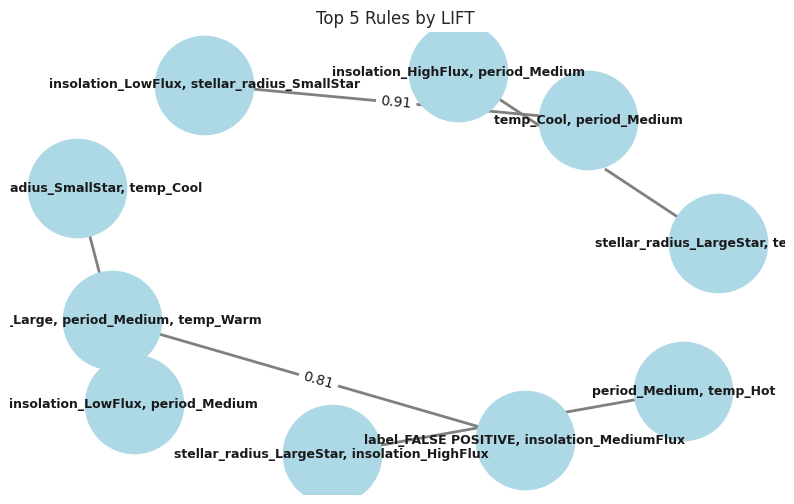

In [112]:
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, k=2.0, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=5000, node_color='lightblue')
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, width=2, edge_color='gray')

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Top 5 Rules by LIFT ")
plt.axis('off')
plt.show()

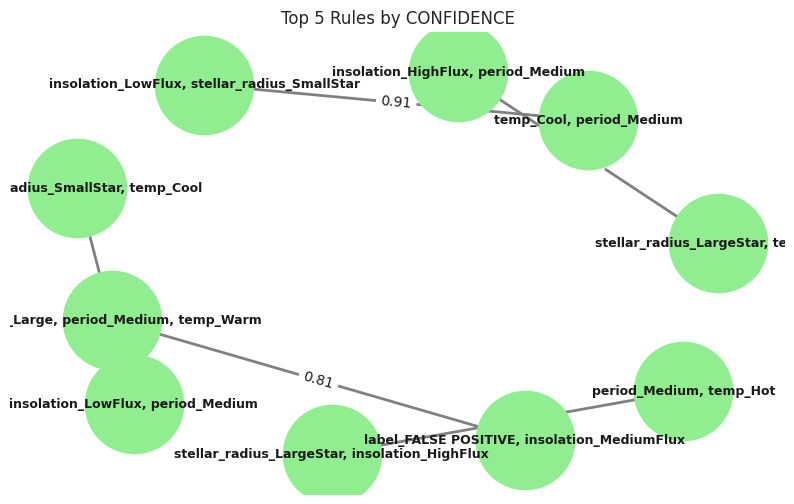

In [111]:
import networkx as nx
import matplotlib.pyplot as plt


top_conf_rules = top_lift.sort_values('confidence', ascending=False).head(5)
G = nx.DiGraph()

for _, row in top_conf_rules.iterrows():
    ant = ', '.join(list(row['antecedents'])).replace('_cat', '')
    con = ', '.join(list(row['consequents'])).replace('_cat', '')
    G.add_edge(ant, con, weight=round(row['confidence'], 2))

plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, k=2.0, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=5000, node_color='lightgreen')
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, width=2, edge_color='gray')

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Top 5 Rules by CONFIDENCE")
plt.axis('off')
plt.show()

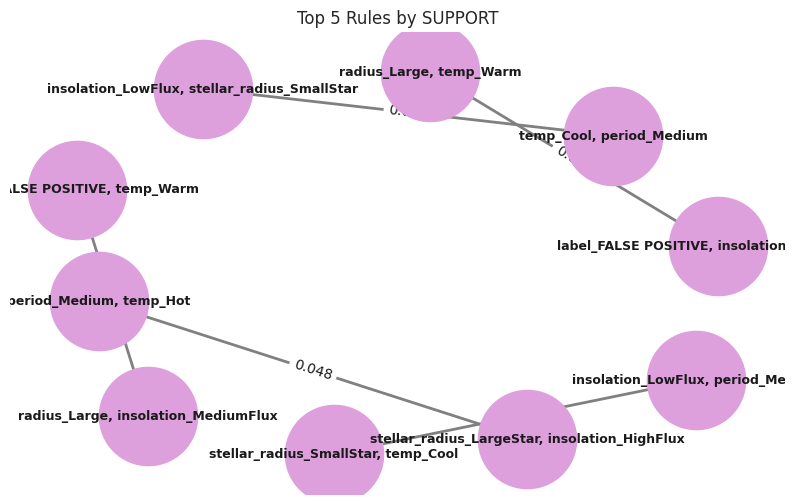

In [110]:
import networkx as nx
import matplotlib.pyplot as plt


top_supp_rules = top_lift.sort_values('support', ascending=False).head(5)
G = nx.DiGraph()

for _, row in top_supp_rules.iterrows():
    ant = ', '.join(list(row['antecedents'])).replace('_cat', '')
    con = ', '.join(list(row['consequents'])).replace('_cat', '')
    G.add_edge(ant, con, weight=round(row['support'], 3))

plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, k=2.5, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=5000, node_color='plum')
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, width=2, edge_color='gray')
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Top 5 Rules by SUPPORT")
plt.axis('off')
plt.show()

min_support = 0.04
min_confidence = 0.6